# Gráficas Implícitas, Paramétricas, Polares y Campos Vectoriales — Actividad 8 MCA2
**Alumno:Luis Gustavo Cortes Leon**

---

## Actividad 1 — Funciones Explícitas
### Composiciones de $f(x)=\sqrt{-x}$ y $g(x)=\ln x$

- $f\circ g = \sqrt{-\ln x}$ — dominio $x\in(0,1]$
- $g\circ f = \ln(\sqrt{-x})$ — dominio $x<0$
- $f\cdot g$ — dominio vacío $\emptyset$

<lambdifygenerated-98>:2: RuntimeWarning: divide by zero encountered in log
  return sqrt(-log(x))


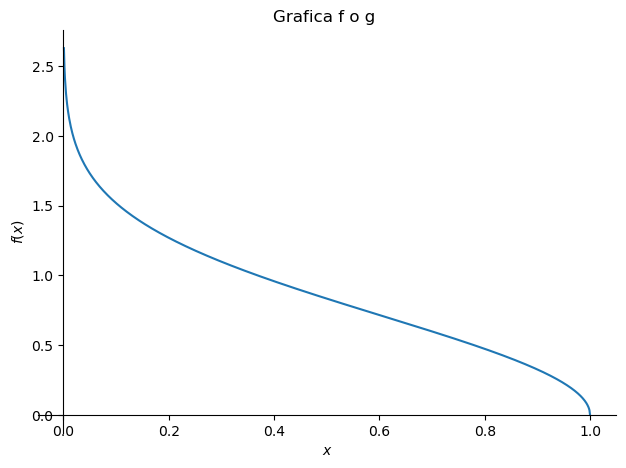

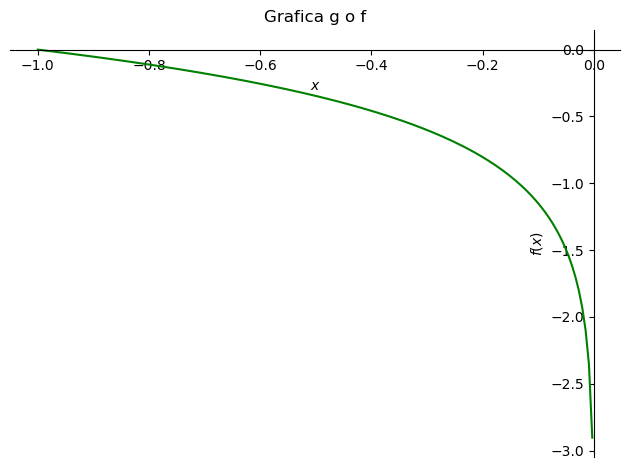

In [ ]:
from sympy import sin, symbols, Abs, ln, sqrt

from sympy.plotting import plot

def f(x):
  return sqrt(-x)

def g(x):
  return ln(x)

x = symbols('x')

plot(f(g(x)), (x, 0 , 1), title= 'Grafica f o g ')
plot(g(f(x)), (x , -1, 5,), line_color='green', title='Grafica g o f')


### Función de Sungkon Chang
$$f(x)=\sum_{k=1}^{100}\left(\frac{\sin(2\pi k^2 x)}{4\pi^2 k^5}+\frac{x^2}{2k}\right)$$

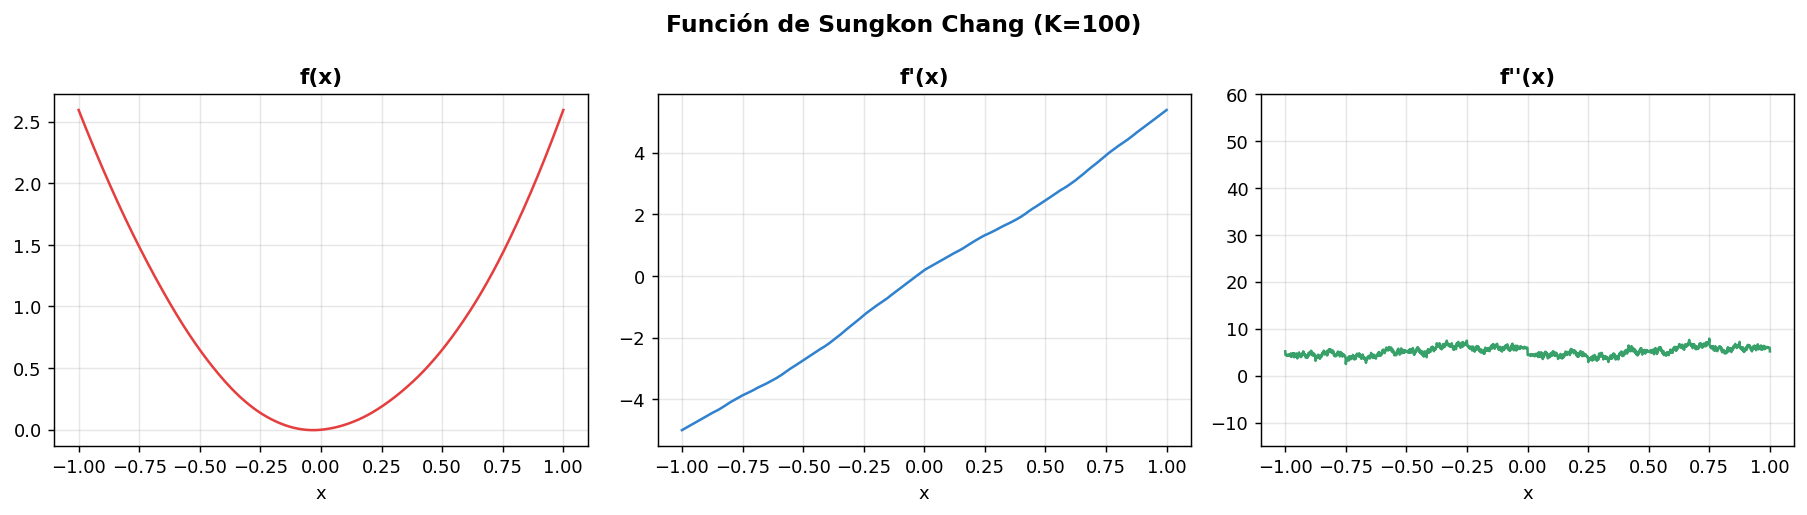

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1, 1, 2000)
K = range(1, 101)

# f, f', f'' acumuladas en un solo loop para eficiencia
f = f1 = f2 = 0
for k in K:
    w = 2*np.pi*k**2
    f  += np.sin(w*x)/(4*np.pi**2*k**5) + x**2/(2*k)
    f1 += w*np.cos(w*x)/(4*np.pi**2*k**5) + x/k
    f2 += -w**2*np.sin(w*x)/(4*np.pi**2*k**5) + 1/k

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, y, title, color in zip(axes,
        [f, f1, f2],
        ["f(x) — aparentemente suave", "f'(x) — empieza a oscilar", "f''(x) — comportamiento salvaje"],
        ['#e53e3e','#3182ce','#38a169']):
    ax.plot(x, y, color=color, lw=1.4)
    ax.set_title(title, fontweight='bold'); ax.grid(alpha=.3); ax.set_xlabel('x')
axes[2].set_ylim(-15, 60)   # f'' explota, recortamos para visualizar
plt.suptitle('Función de Sungkon Chang (K=100)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Actividad 2 — Funciones Implícitas
### $x^2 + y^3 - 2y = 3$

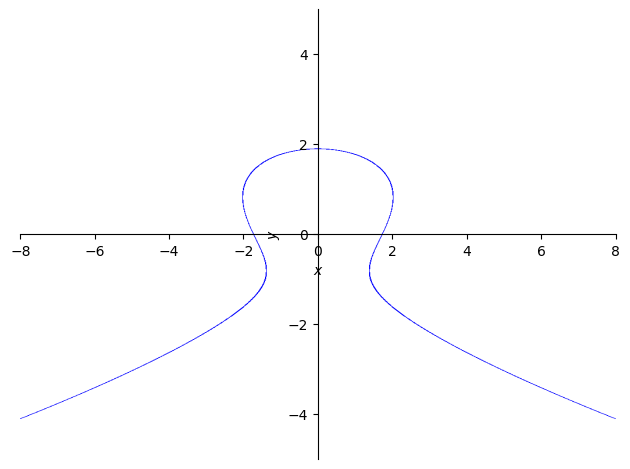

In [ ]:
from sympy import symbols, Eq
from sympy import plot_implicit
x, y = symbols('x y')
plot_implicit(Eq(x**2 + (y**3 - 2*y), 3), (x, -8, 8),
              (y, -5, 5));

### Ecuación de Van der Waals
Despejamos a P de la ecuacion
$$\left(P+\frac{5}{V^2}\right)(V-0.03)=9.7 \implies P=\frac{9.7}{V-0.03}-\frac{5}{V^2}$$

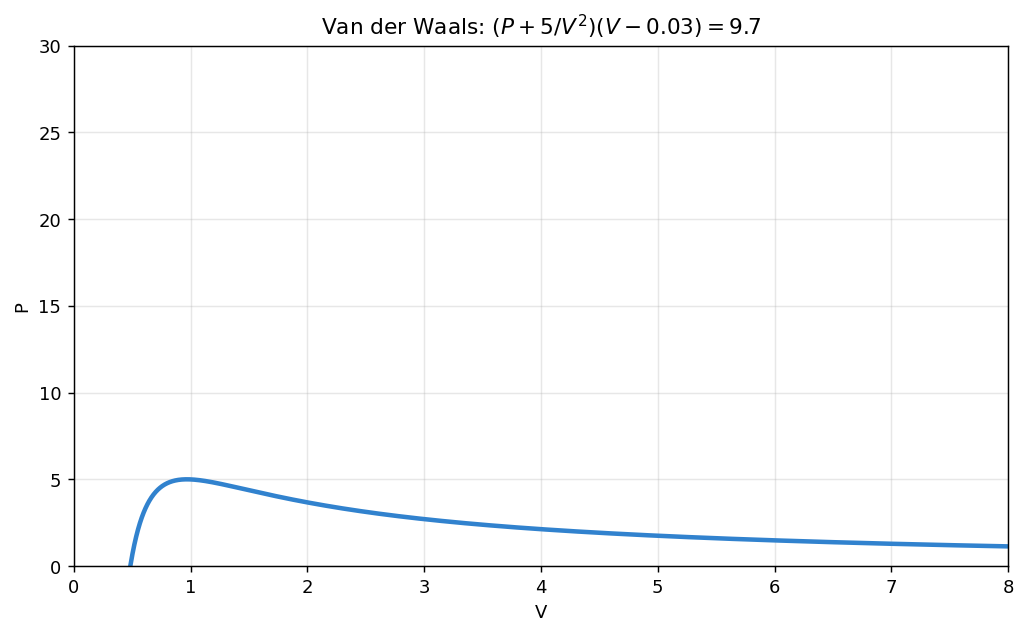

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

V = np.linspace(0.04, 8, 3000)
P = 9.7/(V - 0.03) - 5/V**2        # P despejada
mask = (P > 0) & (P < 50)           # rango físico relevante

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(V[mask], P[mask], color='#3182ce', lw=2.5)
ax.set(title=r'Van der Waals: $(P+5/V^2)(V-0.03)=9.7$',
       xlabel='V', ylabel='P', xlim=(0,8), ylim=(0,30))
ax.grid(alpha=.3); plt.tight_layout(); plt.show()


## Actividad 3 — Función Paramétrica
$$x(t)=\cos t+\tfrac12\cos 7t+\tfrac13\sin 17t,\quady\(t)=\sin t+\tfrac12\sin 7t+\tfrac13\cos 17t,\quad 0\le t\le 14\pi$$

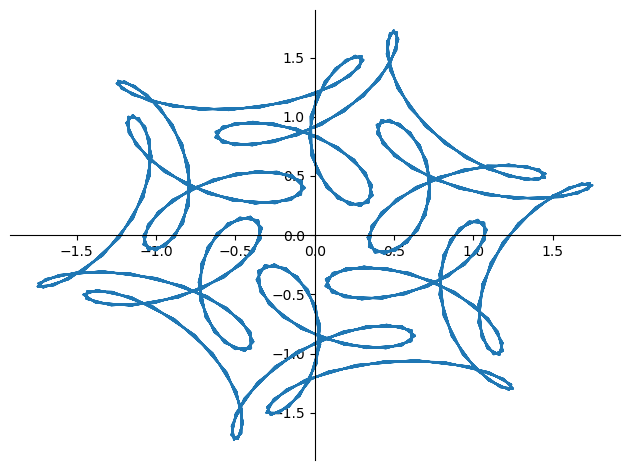

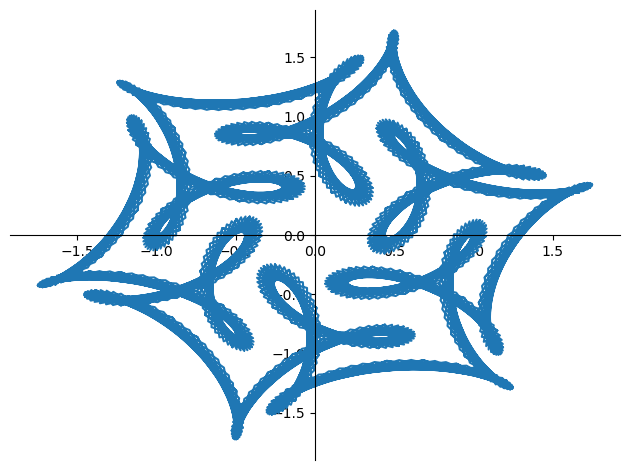

In [ ]:
from sympy import symbols, cos, sin, exp, pi
from sympy import plot_parametric

t = symbols('t')

#Funcion que regresa x(t)
def x(t):
    return cos(t) + .5*cos(7*t) + (1/3)*sin(17*t)

#Funcion que regresa y(t)
def y(t):
    return sin(t) + .5*sin(7*t) + (1/3)*cos(17*t) 

grafxy = plot_parametric(x(t), y(t), (t, -6*pi, 6*pi));
grafxyt = plot_parametric(x(t), y(t), (t, -50, 50));



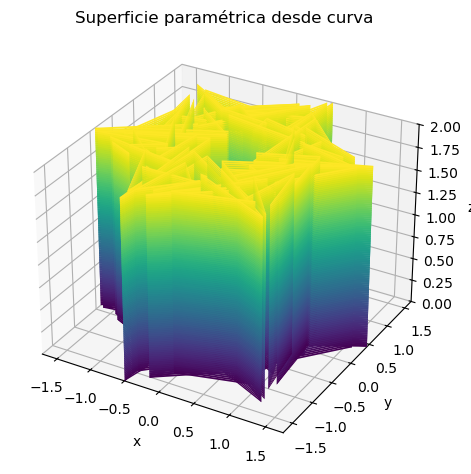

In [ ]:
"""
======================
3D surface (parametric)
======================
"""
from sympy import symbols, cos, sin, pi
from sympy.plotting import plot3d_parametric_surface

u, v = symbols('u v')

# x(t) y y(t) 
x = cos(u) + cos(7*u)/2 + sin(17*u)/3
y = sin(u) + sin(7*u)/2 + cos(17*u)/3
z = v                                    # 

plot3d_parametric_surface(x, y, z,
    (u, 0, 14*pi),   # rango
    (v, 0, 2),       # altura
    title='Superficie paramétrica desde curva')

## Actividad 4 — Coordenadas Polares
### Flor $r=3\cos(h\theta)$

Se observa que si: 
- h **par** → $2h$ pétalos
- h **impar** → $h$ pétalos

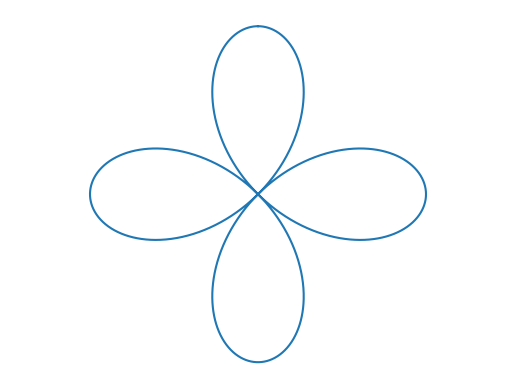

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h = 1

theta = np.linspace(0, 2 * np.pi, 4000)
r = 3 * np.cos(2 * theta)
x = r * np.sin(theta)
y = r * np.cos(theta)

plt.axis('off')
plt.axis('equal')
plt.plot(x,y)

## Actividad 5:
Grafica las siguientes funciones dadas en coordenadas polares obteniendo las coordenadas x,y parametrizadas

* 1) Cardioide
\begin{align}
r(θ) &= a(1 + \cos(θ)) \\
\end{align}

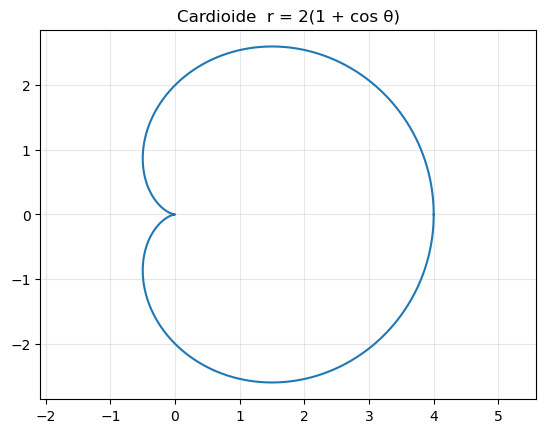

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = 2
theta = np.linspace(0, 2*np.pi, 4000)
r = a * (1 + np.cos(theta))

x = r * np.cos(theta)
y = r * np.sin(theta)

plt.plot(x, y)
plt.title(f'Cardioide  r = {a}(1 + cos θ)')
plt.grid(True, alpha=0.3)
plt.axis('equal');


## Actividad 6:
Grafica las siguiente función dadas en coordenadas polares usando la función polar de pyplot

* 1) Espiral Hiperbólica


### Espiral Hiperbólica: $r\theta=c \implies r=c/\theta$

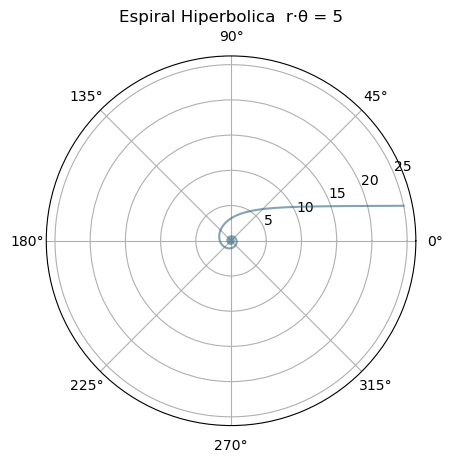

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Espiral Hiperbólica: r·θ = c  →  r = c/θ
c = 5
theta = np.linspace(0.2, 8*np.pi, 5000)
r = c / theta

plt.polar(theta, r, color=(.2,.4,.5,.6));
plt.title(f'Espiral Hiperbolica  r·θ = {c}')
plt.show();
